In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import math
import numpy as np
from matplotlib.ticker import LogFormatterMathtext, FixedLocator, FuncFormatter

In [2]:
v1 = pd.read_csv("../results/timings/simulation_timings_v1.csv")
v2 = pd.read_csv("../results/timings/simulation_timings_v2.csv")

output = (
    pd.concat([v1, v2], keys=["naive", "optimized"])
    .reset_index(level=0)
    .rename(columns={"level_0": "implementation"})
)

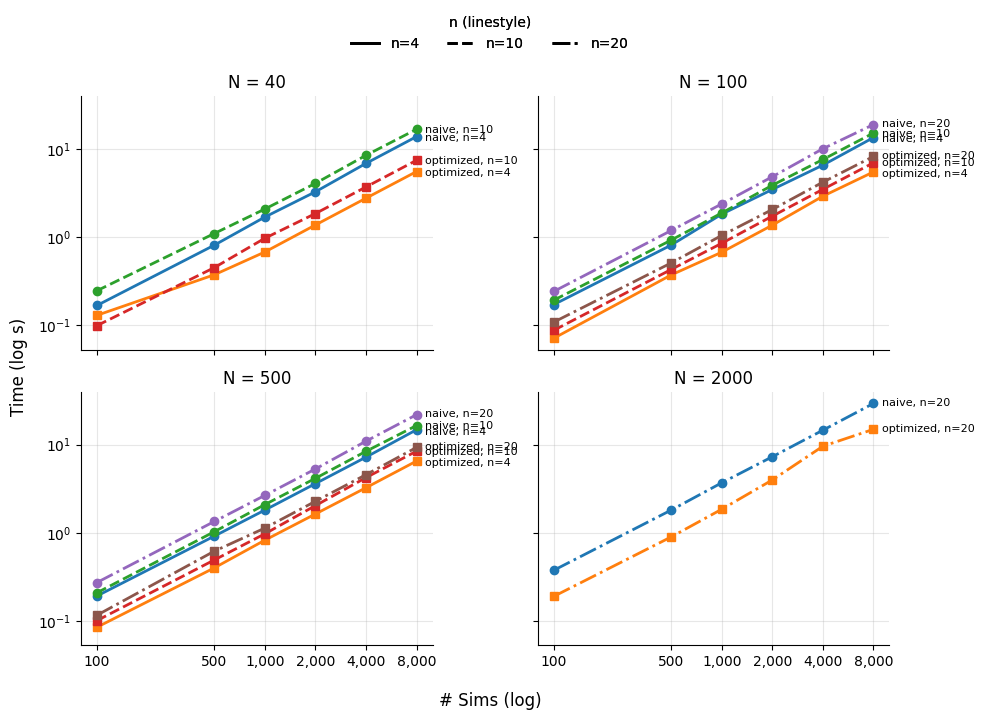

In [ ]:
# === config ===
row_var = "N"  # facets
col_var = "n"  # linestyle
impl_var = "implementation"  # color+marker
x_max_pad = None  # e.g., 4000 to extend to the right; or None

# ---- levels ----
row_vals = sorted(output[row_var].unique())
col_vals = sorted(output[col_var].unique())
impl_levels = sorted(output[impl_var].unique(), key=lambda s: str(s).lower())

# ---- styles ----
linestyles = ["solid", "dashed", "dashdot", "dotted"]
ls_map = {cv: linestyles[i % len(linestyles)] for i, cv in enumerate(col_vals)}
markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
impl_mark = {impl: markers[i % len(markers)] for i, impl in enumerate(impl_levels)}


def label_right(ax, x, y, text, dy=0.0):
    xmin, xmax = ax.get_xlim()
    dx = 0.02 * (xmax - xmin) if xmax > xmin else 0.0
    ax.text(x + dx, y * (1 + dy), f"  {text}", va="center", fontsize=8, clip_on=False)


# paginate into 2x2
panels_per_fig = 4
num_pages = math.ceil(len(row_vals) / panels_per_fig)

for page in range(num_pages):
    rows_this_page = row_vals[page * panels_per_fig : (page + 1) * panels_per_fig]

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    axes = np.array(axes).reshape(2, 2)

    seen_cols = set()
    page_df = output[output[row_var].isin(rows_this_page)]

    # union of x levels on this page (we'll use these as log-x ticks & labels)
    x_levels = sorted(page_df["n_sim"].unique())

    for k, rv in enumerate(rows_this_page):
        i, j = divmod(k, 2)
        ax = axes[i, j]

        sub_r = output[output[row_var] == rv].copy()
        ax.set_title(f"{row_var} = {rv}")

        sub_r.sort_values(["n_sim", impl_var, col_var], inplace=True)

        for cv in col_vals:
            sub_rc = sub_r[sub_r[col_var] == cv]
            if sub_rc.empty:
                continue
            seen_cols.add(cv)
            dy = (list(ls_map.values()).index(ls_map[cv]) - 1.5) * 0.03

            for impl, group in sub_rc.groupby(impl_var):
                group = group.sort_values("n_sim")
                ax.plot(
                    group["n_sim"],
                    group["time_seconds"],
                    linestyle=ls_map[cv],
                    marker=impl_mark[impl],
                    linewidth=2,
                )
                x_end = group["n_sim"].iloc[-1]
                y_end = group["time_seconds"].iloc[-1]
                label_right(ax, x_end, y_end, f"{impl}, {col_var}={cv}", dy=dy)

        # ---- LOG X-AXIS with original-number labels ----
        ax.set_xscale("log")
        ax.xaxis.set_major_locator(FixedLocator(x_levels))  # ticks at your n_sim values
        ax.xaxis.set_major_formatter(
            FuncFormatter(
                lambda v, pos: f"{int(v):,}"
                if v in x_levels
                else ""  # 100, 500, 1,000, 2,000 …
            )
        )
        # kill minor ticks on x to reduce clutter
        ax.tick_params(axis="x", which="minor", bottom=False)

        if x_max_pad is not None and len(x_levels):
            ax.set_xlim(min(x_levels), x_max_pad)

    # hide unused panels
    if len(rows_this_page) < panels_per_fig:
        for k in range(len(rows_this_page), panels_per_fig):
            i, j = divmod(k, 2)
            axes[i, j].axis("off")

    # ---- LOG Y-AXIS with decade ticks only ----
    y_all = page_df["time_seconds"]
    y_all = y_all[y_all > 0]
    if len(y_all):
        decade_lo = int(np.floor(np.log10(y_all.min())))
        decade_hi = int(np.ceil(np.log10(y_all.max())))
        major_ticks = 10.0 ** np.arange(decade_lo, decade_hi + 1)
    else:
        major_ticks = 10.0 ** np.arange(-1, 4)

    for ax in axes.ravel():
        if not ax.has_data():
            continue
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(FixedLocator(major_ticks))
        ax.yaxis.set_major_formatter(LogFormatterMathtext())
        # only major gridlines
        ax.minorticks_off()
        ax.grid(True, which="major", alpha=0.30)
        ax.grid(False, which="minor")
        # clean frame + room for labels
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.margins(x=0.05)

    # shared labels
    fig.supxlabel("# Sims (log)")
    fig.supylabel("Time (log s)")

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

In [4]:
import os
import re
import pstats
import pandas as pd
from functools import reduce


# ---------- 1) Loader: .prof/.pstats -> tidy DataFrame ----------
def profile_to_df(src, strip_dirs=True):
    """
    src: path to .prof file OR an existing pstats.Stats object.
    Returns a tidy DataFrame with a stable 'func_key'.
    """
    st = pstats.Stats(src) if isinstance(src, (str, os.PathLike)) else src
    if strip_dirs:
        st.strip_dirs()

    def func_key(func_tuple, include_line=True):
        filename, lineno, funcname = func_tuple
        # normalize filename -> module-ish name
        if filename.startswith("{built-in"):
            base = "builtins"
        else:
            base = os.path.basename(filename) if strip_dirs else filename
            base = re.sub(r"\.pyc?$", "", base)
        return f"{base}:{funcname}:{lineno}" if include_line else f"{base}:{funcname}"

    rows = []
    for func, (cc, nc, tt, ct, callers) in st.stats.items():
        filename, lineno, funcname = func
        rows.append(
            {
                "file": os.path.basename(filename) if strip_dirs else filename,
                "line": lineno,
                "func": funcname,
                "func_key": func_key(
                    func, include_line=False
                ),  # stable join key (file:func:line)
                "ncalls": nc,  # total calls (incl. recursion)
                "ccalls": cc,  # primitive calls
                "tottime": tt,  # time in function body (excl. subcalls)
                "cumtime": ct,  # incl. subcalls
            }
        )

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # convenience cols
    df["percall_tottime"] = df["tottime"] / df["ncalls"].where(df["ncalls"] != 0, 1)
    df["percall_cumtime"] = df["cumtime"] / df["ncalls"].where(df["ncalls"] != 0, 1)
    df["tottime_pct"] = df["tottime"] / df["tottime"].sum()
    df["cumtime_pct"] = df["cumtime"] / df["cumtime"].sum()
    return df.sort_values("cumtime", ascending=False).reset_index(drop=True)


# ---------- 2) Comparator: accepts DataFrames ----------
def compare_profiles_df(
    df_a, df_b, labels=("old", "new"), key="cumtime", top=30, join_on="func_key"
):
    """
    Outer-join two profile DataFrames on join_on (default 'func_key'),
    compute deltas for key metrics, and return the top rows by Δkey (new-old).
    """
    a, b = labels
    # pick columns to carry through for each side
    base_cols = [
        "file",
        "line",
        "func",
        "ncalls",
        "ccalls",
        "tottime",
        "cumtime",
        "percall_tottime",
        "percall_cumtime",
        "tottime_pct",
        "cumtime_pct",
    ]
    keep_a = [join_on] + base_cols
    keep_b = [join_on] + base_cols

    A = df_a[keep_a].copy().add_suffix(f"_{a}")
    B = df_b[keep_b].copy().add_suffix(f"_{b}")
    A = A.rename(columns={f"{join_on}_{a}": join_on})
    B = B.rename(columns={f"{join_on}_{b}": join_on})

    cmp_df = pd.merge(A, B, on=join_on, how="outer")

    # deltas (new - old)
    for m in [
        "tottime",
        "cumtime",
        "percall_tottime",
        "percall_cumtime",
        "tottime_pct",
        "cumtime_pct",
        "ncalls",
        "ccalls",
    ]:
        ma, mb = f"{m}_{a}", f"{m}_{b}"
        if ma in cmp_df.columns and mb in cmp_df.columns:
            cmp_df[f"Δ{m}({b}-{a})"] = cmp_df[mb].fillna(0) - cmp_df[ma].fillna(0)

    # sort by chosen signal
    cmp_df = cmp_df.sort_values(f"Δ{key}({b}-{a})", ascending=False)
    return cmp_df.head(top)


# ---------- 3) (Optional) N-way stitcher ----------
def stitch_profiles_dfs(dfs, labels, join_on="func_key"):
    """
    Outer-join many profile DataFrames on join_on for side-by-side comparison.
    """

    def rename(df, lab):
        base_cols = [
            "file",
            "line",
            "func",
            "ncalls",
            "ccalls",
            "tottime",
            "cumtime",
            "percall_tottime",
            "percall_cumtime",
            "tottime_pct",
            "cumtime_pct",
        ]
        cols = [join_on] + base_cols
        out = df[cols].copy().add_suffix(f"_{lab}")
        return out.rename(columns={f"{join_on}_{lab}": join_on})

    renamed = [rename(d, lb) for d, lb in zip(dfs, labels)]
    return reduce(lambda L, R: pd.merge(L, R, on=join_on, how="outer"), renamed)

In [5]:
df1, df2 = (
    profile_to_df("../results/timings/unit_2_project.prof"),
    profile_to_df("../results/timings/unit_3_project.prof"),
)
# compare_profiles_df(df1, df2, labels=("v1","v2"), join_on="func_key", top=100)

key_fns = ["methods:fit_parametricEB", "methods:fit_mle", "methods:fit_semiBayes"]


compare_profiles_df(
    df1[df1.func_key.isin(key_fns)],
    df2[df2.func_key.isin(key_fns)],
    labels=("v1", "v2"),
)[["func_key", "tottime_v1", "tottime_v2", "Δtottime(v2-v1)"]]

,func_key,tottime_v1,tottime_v2,Δtottime(v2-v1)
0,methods:fit_mle,0.160261,1.823149,1.662888
2,methods:fit_semiBayes,4.247639,4.401580,0.153941
1,methods:fit_parametricEB,7.687010,5.227119,-2.459892


In [6]:
key_funcs = ["generate_design_matrix", "fit_mle", "fit_semiBayes", "fit_parametricEB"]
comparison = pd.merge(
    df1[df1["func"].isin(key_funcs)][["func", "tottime", "cumtime", "percall_tottime"]],
    df2[df2["func"].isin(key_funcs)][["func", "tottime", "cumtime", "percall_tottime"]],
    on="func",
    suffixes=("_v1", "_v2"),
)

comparison["percall_tottime_diff"] = (
    comparison["percall_tottime_v2"] - comparison["percall_tottime_v1"]
)
comparison.sort_values("percall_tottime_diff", ascending=False)[
    ["func", "percall_tottime_v1", "percall_tottime_v2", "percall_tottime_diff"]
].drop_duplicates()

,func,percall_tottime_v1,percall_tottime_v2,percall_tottime_diff
0,fit_mle,0.000002,0.000025,2.279997e-05
2,fit_semiBayes,0.000020,0.000020,7.135993e-07
3,generate_design_matrix,0.000085,0.000079,-6.431421e-06
1,fit_parametricEB,0.000107,0.000073,-3.415627e-05


In [7]:
df2.sort_values("tottime", ascending=False)

df1[df1["func"].isin(key_funcs)]

,file,line,func,func_key,ncalls,ccalls,tottime,cumtime,percall_tottime,percall_cumtime,tottime_pct,cumtime_pct
19,methods.py,28,fit_mle,methods:fit_mle,72732,72732,0.160261,47.125431,0.000002,0.000648,0.000615,0.012753
45,methods.py,60,fit_parametricEB,methods:fit_parametricEB,72006,72006,7.687010,19.916602,0.000107,0.000277,0.029506,0.005390
53,methods.py,177,fit_semiBayes,methods:fit_semiBayes,216010,216010,4.247639,12.661412,0.000020,0.000059,0.016304,0.003427
57,dgps.py,195,generate_design_matrix,dgps:generate_design_matrix,72732,72732,6.190427,12.031995,0.000085,0.000165,0.023762,0.003256
